# Multi-Factor Equity Screener — Nifty 50 (India)

This notebook builds a **multi-factor equity screener** for the **Nifty 50** universe — the 50 largest, most liquid stocks on the National Stock Exchange (NSE) of India — ranking them using four classic factor families: **Value**, **Momentum**, **Quality**, and **Low Volatility**, combined into a single composite score. It pulls real market and fundamental data from Yahoo Finance (via `yfinance`, using NSE `.NS` tickers), engineers factor signals, cross-sectionally standardizes them (z-scores), blends them into a weighted composite, and visualizes the results with ranking charts, a factor correlation heatmap, and sector breakdowns. All monetary fundamentals (market cap, book value, etc.) are reported in **INR** as returned by Yahoo Finance. The screener is designed to degrade gracefully: tickers with missing or unavailable fundamental data — including a few very recently renamed/demerged Nifty constituents — are flagged and excluded from the affected factor rather than crashing the pipeline.

In [1]:
# ==============================================================
# Cell 2: Installs & Imports
# ==============================================================
!pip install -q yfinance pandas numpy matplotlib seaborn plotly scipy tabulate

import warnings
warnings.filterwarnings("ignore")

import time
import datetime as dt
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

import yfinance as yf

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", None)

print("Environment ready:")
print(f"  yfinance   : {yf.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")

Environment ready:
  yfinance   : 0.2.66
  pandas     : 2.2.2
  numpy      : 2.0.2


## 1. Universe & Configuration

We define the stock universe (the current 50 official Nifty 50 constituents, spanning banks, IT services, energy, FMCG, pharma, autos, metals, and more), the lookback windows used for momentum and volatility, and the weights that combine the four factors into a single composite score. Everything is centralized in a `Config` object so the screener can be re-run on a different universe (e.g. Nifty Next 50, Nifty Bank) or weighting scheme without touching downstream code. Note the `.NS` suffix on every ticker — this tells Yahoo Finance to fetch the NSE-listed share class rather than a US listing.

In [2]:
# ==============================================================
# Cell 4: Universe & Configuration
# ==============================================================

@dataclass
class ScreenerConfig:
    # NSE tickers require the ".NS" suffix on Yahoo Finance (e.g. "RELIANCE.NS").
    # Universe = current official Nifty 50 constituents (NSE Indices, Dec 2025 reconstitution).
    tickers: list = field(default_factory=lambda: [
        "RELIANCE.NS", "ONGC.NS", "COALINDIA.NS",                                   # Energy / Oil & Gas
        "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS", "AXISBANK.NS",     # Banks
        "BAJFINANCE.NS", "BAJAJFINSV.NS", "JIOFIN.NS", "SHRIRAMFIN.NS",              # Financial Services / NBFC
        "HDFCLIFE.NS", "SBILIFE.NS",                                                 # Insurance
        "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS",                   # IT Services
        "BHARTIARTL.NS",                                                             # Telecom
        "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "TATACONSUM.NS",                  # FMCG
        "SUNPHARMA.NS", "CIPLA.NS", "DRREDDY.NS", "APOLLOHOSP.NS", "MAXHEALTH.NS",   # Healthcare / Pharma
        "MARUTI.NS", "M&M.NS", "TMPV.NS", "BAJAJ-AUTO.NS", "EICHERMOT.NS",           # Autos
        "LT.NS", "ULTRACEMCO.NS", "GRASIM.NS",                                       # Industrials / Cement
        "TATASTEEL.NS", "JSWSTEEL.NS", "HINDALCO.NS", "ADANIENT.NS",                 # Metals & Mining
        "NTPC.NS", "POWERGRID.NS",                                                   # Utilities / Power
        "ASIANPAINT.NS", "TITAN.NS",                                                 # Consumer Durables
        "ADANIPORTS.NS", "INDIGO.NS",                                                # Services / Aviation
        "ETERNAL.NS", "TRENT.NS",                                                    # Consumer Services / Retail
        "BEL.NS",                                                                    # Capital Goods / Defense
    ])
    lookback_days: int = 400          # price history window (covers 12M momentum + buffer)
    momentum_window_short: int = 63   # ~3 months of trading days
    momentum_window_long: int = 252   # ~12 months of trading days
    volatility_window: int = 126      # ~6 months of trading days
    factor_weights: dict = field(default_factory=lambda: {
        "value": 0.30,
        "momentum": 0.25,
        "quality": 0.30,
        "low_volatility": 0.15,
    })
    currency_symbol: str = "\u20b9"    # Indian Rupee sign, used only for display/formatting
    request_pause_sec: float = 0.15   # polite pause between per-ticker fundamental calls
    max_retries: int = 3

CONFIG = ScreenerConfig()

assert abs(sum(CONFIG.factor_weights.values()) - 1.0) < 1e-9, "Factor weights must sum to 1.0"

print(f"Universe size        : {len(CONFIG.tickers)} tickers (Nifty 50, NSE)")
print(f"Price lookback (days): {CONFIG.lookback_days}")
print(f"Factor weights        : {CONFIG.factor_weights}")
print("\nNote: A handful of Nifty constituents were renamed/demerged/added very recently")
print("(e.g. TMPV.NS, ETERNAL.NS, INDIGO.NS, JIOFIN.NS, MAXHEALTH.NS). If Yahoo Finance")
print("doesn't yet have full history or fundamentals for one of these, it will be logged")
print("and excluded automatically by the error handling in Cell 6 -- not a bug.")

Universe size        : 50 tickers (Nifty 50, NSE)
Price lookback (days): 400
Factor weights        : {'value': 0.3, 'momentum': 0.25, 'quality': 0.3, 'low_volatility': 0.15}

Note: A handful of Nifty constituents were renamed/demerged/added very recently
(e.g. TMPV.NS, ETERNAL.NS, INDIGO.NS, JIOFIN.NS, MAXHEALTH.NS). If Yahoo Finance
doesn't yet have full history or fundamentals for one of these, it will be logged
and excluded automatically by the error handling in Cell 6 -- not a bug.


## 2. Data Acquisition

We pull two kinds of real data per ticker:

1. **Price history** (via `yf.download`, batched) — used for momentum and volatility factors.
2. **Fundamental snapshot** (via `Ticker.info` / `Ticker.get_info`) — used for value and quality factors (P/E, P/B, EV/EBITDA, ROE, margins, debt/equity, sector).

Network calls are wrapped in retry logic with exponential backoff, and any ticker that fails outright is logged and excluded rather than crashing the run. Missing individual fields are set to `NaN` and handled later during factor scoring (a stock isn't dropped just because one field is missing — only the affected factor score is).

In [3]:
# ==============================================================
# Cell 6: Data Acquisition (prices + fundamentals)
# ==============================================================

def fetch_price_history(tickers: list, lookback_days: int) -> pd.DataFrame:
    # Download adjusted close prices for all tickers in one batched call.
    end = dt.datetime.today()
    start = end - dt.timedelta(days=int(lookback_days * 1.6))  # buffer for weekends/holidays

    try:
        raw = yf.download(
            tickers=tickers,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False,
            group_by="ticker",
            threads=True,
        )
    except Exception as exc:
        print(f"[WARN] Batched price download failed ({exc}); falling back to per-ticker fetch.")
        raw = None

    close_frames = {}
    if raw is not None and not raw.empty:
        for tkr in tickers:
            try:
                series = raw[tkr]["Close"].dropna()
                if len(series) > 20:
                    close_frames[tkr] = series
            except (KeyError, TypeError):
                continue

    # Fill in any tickers missing from the batch call individually
    missing = [t for t in tickers if t not in close_frames]
    for tkr in missing:
        for attempt in range(CONFIG.max_retries):
            try:
                series = yf.Ticker(tkr).history(start=start, end=end, auto_adjust=True)["Close"].dropna()
                if len(series) > 20:
                    close_frames[tkr] = series
                break
            except Exception:
                time.sleep(CONFIG.request_pause_sec * (attempt + 1))
        else:
            print(f"[WARN] Could not fetch price history for {tkr}; excluding from universe.")

    price_df = pd.DataFrame(close_frames).sort_index()
    price_df = price_df.dropna(axis=1, thresh=int(len(price_df) * 0.8))  # drop tickers with too many gaps
    return price_df


def fetch_fundamentals(tickers: list) -> pd.DataFrame:
    # Pull a fundamental snapshot per ticker, tolerating missing fields/tickers.
    records = []
    for tkr in tickers:
        info = {}
        for attempt in range(CONFIG.max_retries):
            try:
                info = yf.Ticker(tkr).get_info()
                break
            except Exception:
                time.sleep(CONFIG.request_pause_sec * (attempt + 1))
        if not info:
            print(f"[WARN] No fundamental data returned for {tkr}.")
        record = {
            "ticker": tkr,
            "shortName": info.get("shortName", tkr),
            "sector": info.get("sector", "Unknown"),
            "industry": info.get("industry", "Unknown"),
            "marketCap": info.get("marketCap", np.nan),
            "trailingPE": info.get("trailingPE", np.nan),
            "priceToBook": info.get("priceToBook", np.nan),
            "enterpriseToEbitda": info.get("enterpriseToEbitda", np.nan),
            "returnOnEquity": info.get("returnOnEquity", np.nan),
            "profitMargins": info.get("profitMargins", np.nan),
            "debtToEquity": info.get("debtToEquity", np.nan),
            "revenueGrowth": info.get("revenueGrowth", np.nan),
            "earningsGrowth": info.get("earningsGrowth", np.nan),
        }
        records.append(record)
        time.sleep(CONFIG.request_pause_sec)

    fundamentals_df = pd.DataFrame(records).set_index("ticker")
    return fundamentals_df


print("Fetching price history for the universe (this may take ~30-60 seconds)...")
price_history = fetch_price_history(CONFIG.tickers, CONFIG.lookback_days)
print(f"  -> Retrieved prices for {price_history.shape[1]} / {len(CONFIG.tickers)} tickers, "
      f"{price_history.shape[0]} trading days.")

print("\nFetching fundamental snapshots (one call per ticker)...")
fundamentals = fetch_fundamentals(list(price_history.columns))
print(f"  -> Retrieved fundamentals for {fundamentals.shape[0]} tickers.")

missing_fund_pct = fundamentals.drop(columns=["shortName", "sector", "industry"]).isna().mean().mean() * 100
print(f"  -> Average missing-field rate across fundamental columns: {missing_fund_pct:.1f}%")

fundamentals.head()

Fetching price history for the universe (this may take ~30-60 seconds)...
  -> Retrieved prices for 50 / 50 tickers, 436 trading days.

Fetching fundamental snapshots (one call per ticker)...
  -> Retrieved fundamentals for 50 tickers.
  -> Average missing-field rate across fundamental columns: 10.0%


,shortName,sector,industry,marketCap,trailingPE,priceToBook,enterpriseToEbitda,returnOnEquity,profitMargins,debtToEquity,revenueGrowth,earningsGrowth
ticker,,,,,,,,,,,,
RELIANCE.NS,RELIANCE INDUSTRIES LTD,Energy,Oil & Gas Refining & Marketing,17849330434048,23.899,1.974,11.578,NaN,0.066,36.653,0.297,-0.224
ONGC.NS,OIL AND NATURAL GAS CORP.,Energy,Oil & Gas Integrated,3044427694080,7.347,0.819,4.313,0.127,0.063,42.548,0.019,0.478
COALINDIA.NS,COAL INDIA LTD,Energy,Thermal Coal,2563694919680,8.226,2.152,5.231,NaN,0.181,11.629,0.451,0.012
HDFCBANK.NS,HDFC BANK LTD,Financial Services,Banks - Regional,11599982100480,16.445,1.912,NaN,0.138,0.268,NaN,0.166,0.181
ICICIBANK.NS,ICICI BANK LTD.,Financial Services,Banks - Regional,10472985198592,18.870,2.753,NaN,0.161,0.275,NaN,0.114,0.138


## 3. Factor Engineering

We now translate raw prices and fundamentals into four factor families:

- **Value**: cheapness relative to earnings, book value, and EBITDA (lower P/E, P/B, EV/EBITDA → higher value score).
- **Momentum**: blended 3-month and 12-month price returns (higher trailing return → higher momentum score).
- **Quality**: profitability and balance-sheet strength (higher ROE and margins, lower leverage → higher quality score).
- **Low Volatility**: inverse of realized volatility over the trailing ~6 months (lower volatility → higher score).

Each raw metric is sign-adjusted so that **higher is always better** before standardization, which keeps the scoring step in Cell 10 simple and consistent.

In [4]:
# ==============================================================
# Cell 8: Factor Engineering
# ==============================================================

def compute_momentum_and_volatility(prices: pd.DataFrame, cfg: ScreenerConfig) -> pd.DataFrame:
    returns = prices.pct_change()

    mom_short = prices.iloc[-1] / prices.iloc[-cfg.momentum_window_short] - 1
    mom_long = prices.iloc[-1] / prices.iloc[-cfg.momentum_window_long] - 1
    blended_momentum = 0.4 * mom_short + 0.6 * mom_long

    realized_vol = returns.tail(cfg.volatility_window).std() * np.sqrt(252)

    out = pd.DataFrame({
        "mom_3m": mom_short,
        "mom_12m": mom_long,
        "momentum_raw": blended_momentum,
        "realized_vol_ann": realized_vol,
    })
    return out


def build_factor_table(prices: pd.DataFrame, fundamentals: pd.DataFrame, cfg: ScreenerConfig) -> pd.DataFrame:
    price_factors = compute_momentum_and_volatility(prices, cfg)
    factors = fundamentals.join(price_factors, how="inner")

    # --- Value: invert multiples so higher = cheaper = better ---
    for col, new_col in [
        ("trailingPE", "value_pe_inv"),
        ("priceToBook", "value_pb_inv"),
        ("enterpriseToEbitda", "value_evebitda_inv"),
    ]:
        safe = factors[col].where(factors[col] > 0)  # negative/zero multiples are not meaningful
        factors[new_col] = 1.0 / safe

    # --- Quality: higher ROE/margins good; higher leverage bad, so invert ---
    factors["quality_roe"] = factors["returnOnEquity"]
    factors["quality_margin"] = factors["profitMargins"]
    safe_dte = factors["debtToEquity"].where(factors["debtToEquity"] >= 0)
    factors["quality_leverage_inv"] = 1.0 / (1.0 + safe_dte / 100.0)

    # --- Momentum & Low Vol already oriented correctly ---
    factors["momentum_score_raw"] = factors["momentum_raw"]
    safe_vol = factors["realized_vol_ann"].where(factors["realized_vol_ann"] > 0)
    factors["low_vol_score_raw"] = 1.0 / safe_vol

    return factors


factor_table = build_factor_table(price_history, fundamentals, CONFIG)

print(f"Factor table built for {factor_table.shape[0]} tickers.")
display_cols = [
    "sector", "trailingPE", "priceToBook", "enterpriseToEbitda",
    "returnOnEquity", "profitMargins", "debtToEquity",
    "momentum_raw", "realized_vol_ann",
]
factor_table[display_cols].head(10)

Factor table built for 50 tickers.


,sector,trailingPE,priceToBook,enterpriseToEbitda,returnOnEquity,profitMargins,debtToEquity,momentum_raw,realized_vol_ann
RELIANCE.NS,Energy,23.899,1.974,11.578,NaN,0.066,36.653,-0.065,0.228
ONGC.NS,Energy,7.347,0.819,4.313,0.127,0.063,42.548,-0.026,0.263
COALINDIA.NS,Energy,8.226,2.152,5.231,NaN,0.181,11.629,0.074,0.242
HDFCBANK.NS,Financial Services,16.445,1.912,NaN,0.138,0.268,NaN,-0.162,0.270
ICICIBANK.NS,Financial Services,18.870,2.753,NaN,0.161,0.275,NaN,0.061,0.221
SBIN.NS,Financial Services,11.467,1.618,NaN,0.155,0.221,NaN,0.186,0.286
KOTAKBANK.NS,Financial Services,19.476,2.182,NaN,NaN,0.285,NaN,0.029,0.245
AXISBANK.NS,Financial Services,14.310,1.773,NaN,0.134,0.360,NaN,0.106,0.276
BAJFINANCE.NS,Financial Services,35.455,6.289,NaN,NaN,0.435,314.833,0.264,0.350
BAJAJFINSV.NS,Financial Services,33.212,4.301,12.595,NaN,0.065,256.404,0.102,0.276


## 4. Cross-Sectional Scoring & Composite Ranking

Raw factor metrics live on very different scales (a P/E ratio vs. a return percentage vs. a volatility figure), so we convert each into a **cross-sectional z-score** — how many standard deviations a stock is above/below the universe average on that metric, on that day. Sub-factors within a family (e.g. the three value metrics) are averaged into a single family z-score, missing data is imputed with a neutral score of 0 (i.e. "average," not penalized), and the four family scores are combined using the configured weights into one **Composite Score**.

In [5]:
# ==============================================================
# Cell 10: Cross-Sectional Z-Score Standardization & Composite Score
# ==============================================================

def zscore(series: pd.Series) -> pd.Series:
    # Cross-sectional z-score; missing values are neutral-imputed to 0 AFTER scoring peers.
    valid = series.dropna()
    if valid.std(ddof=0) == 0 or len(valid) < 2:
        return pd.Series(0.0, index=series.index)
    z = (series - valid.mean()) / valid.std(ddof=0)
    return z.fillna(0.0)


def build_composite_score(factors: pd.DataFrame, cfg: ScreenerConfig) -> pd.DataFrame:
    scores = pd.DataFrame(index=factors.index)

    value_components = ["value_pe_inv", "value_pb_inv", "value_evebitda_inv"]
    quality_components = ["quality_roe", "quality_margin", "quality_leverage_inv"]

    scores["value_z"] = factors[value_components].apply(zscore).mean(axis=1)
    scores["quality_z"] = factors[quality_components].apply(zscore).mean(axis=1)
    scores["momentum_z"] = zscore(factors["momentum_score_raw"])
    scores["low_vol_z"] = zscore(factors["low_vol_score_raw"])

    scores["composite_score"] = (
        cfg.factor_weights["value"] * scores["value_z"]
        + cfg.factor_weights["momentum"] * scores["momentum_z"]
        + cfg.factor_weights["quality"] * scores["quality_z"]
        + cfg.factor_weights["low_volatility"] * scores["low_vol_z"]
    )

    scores["sector"] = factors["sector"]
    scores["shortName"] = factors["shortName"]
    scores = scores.sort_values("composite_score", ascending=False)
    scores["rank"] = np.arange(1, len(scores) + 1)
    return scores


scored = build_composite_score(factor_table, CONFIG)

print("Top 10 by composite score:")
scored[["rank", "shortName", "sector", "value_z", "momentum_z", "quality_z", "low_vol_z", "composite_score"]].head(10)

Top 10 by composite score:


,rank,shortName,sector,value_z,momentum_z,quality_z,low_vol_z,composite_score
COALINDIA.NS,1,COAL INDIA LTD,Energy,2.088,0.099,0.330,0.644,0.847
ONGC.NS,2,OIL AND NATURAL GAS CORP.,Energy,3.595,-0.538,-0.426,0.181,0.843
SHRIRAMFIN.NS,3,SHRIRAM FINANCE LIMITED,Financial Services,0.159,2.673,0.358,-1.872,0.543
SBIN.NS,4,STATE BANK OF INDIA,Financial Services,0.984,0.813,0.081,-0.245,0.486
NTPC.NS,5,NTPC LTD,Utilities,1.521,-0.446,-0.366,1.660,0.484
AXISBANK.NS,6,AXIS BANK LIMITED,Financial Services,0.707,0.301,0.392,-0.069,0.394
JSWSTEEL.NS,7,JSW STEEL LIMITED,Basic Materials,0.699,0.625,-0.332,0.538,0.347
HINDALCO.NS,8,HINDALCO INDUSTRIES LTD,Basic Materials,1.099,1.263,-0.708,-0.577,0.347
BAJAJ-AUTO.NS,9,BAJAJ AUTO LIMITED,Consumer Cyclical,-0.395,1.861,-0.071,0.062,0.335
ICICIBANK.NS,10,ICICI BANK LTD.,Financial Services,0.230,0.017,0.247,1.191,0.326


## 5. Visualization

Four views into the results:

1. A ranked bar chart of the **top 15 and bottom 5** stocks by composite score.
2. A **factor correlation heatmap** to check how independent our four factor families actually are.
3. An interactive **Plotly scatter** of Momentum vs. Quality, sized by market cap and colored by sector.
4. A **sector-level bar chart** of average composite score, to see which sectors screen best right now.

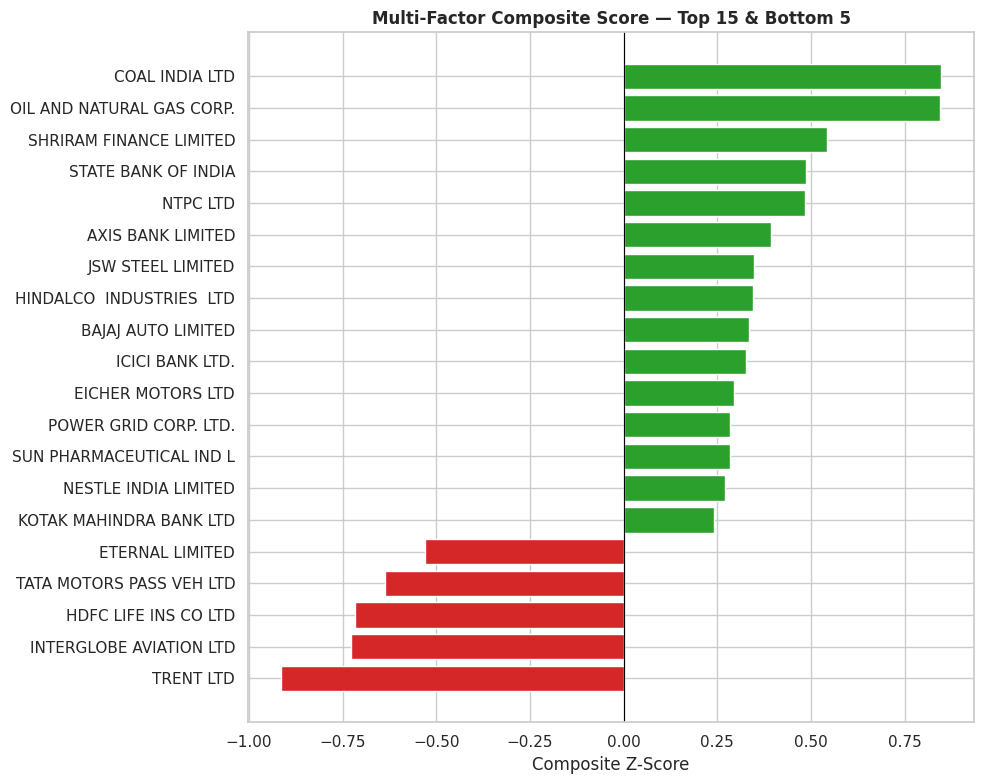

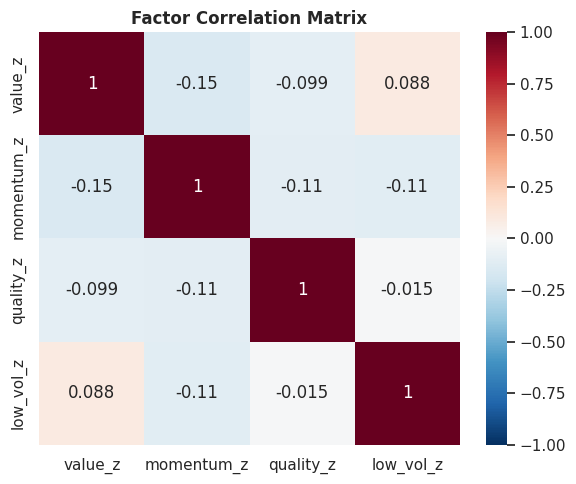

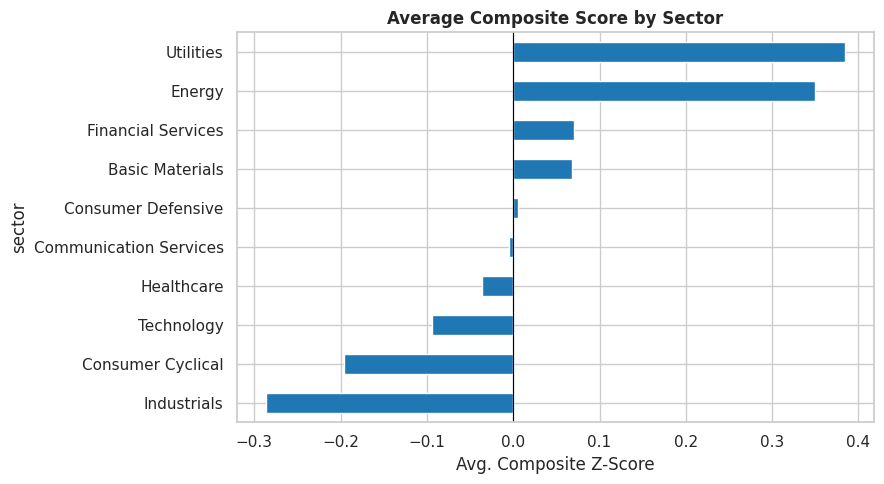

In [7]:
# ==============================================================
# Cell 12: Visualization
# ==============================================================

# --- 1. Top/Bottom composite score bar chart -------------------------------
top_n, bottom_n = 15, 5
plot_df = pd.concat([scored.head(top_n), scored.tail(bottom_n)]).sort_values("composite_score")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in plot_df["composite_score"]]
ax.barh(plot_df["shortName"], plot_df["composite_score"], color=colors)
ax.set_title(f"Multi-Factor Composite Score — Top {top_n} & Bottom {bottom_n}")
ax.set_xlabel("Composite Z-Score")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# --- 2. Factor correlation heatmap ------------------------------------------
factor_corr = scored[["value_z", "momentum_z", "quality_z", "low_vol_z"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(factor_corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Factor Correlation Matrix")
plt.tight_layout()
plt.show()

# --- 3. Interactive Momentum vs Quality scatter ------------------------------
scatter_df = scored.join(factor_table[["marketCap"]])
scatter_df["marketCap_display"] = scatter_df["marketCap"].fillna(scatter_df["marketCap"].median())

fig = px.scatter(
    scatter_df.reset_index(),
    x="momentum_z", y="quality_z",
    size="marketCap_display", color="sector",
    hover_name="shortName",
    hover_data={"index": True, "composite_score": ":.2f", "marketCap_display": False},
    title="Momentum vs. Quality (bubble size = market cap)",
    labels={"momentum_z": "Momentum Z-Score", "quality_z": "Quality Z-Score"},
)
fig.update_layout(height=550)
fig.show()

# --- 4. Sector-level average composite score --------------------------------
sector_avg = scored.groupby("sector")["composite_score"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
sector_avg.plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Average Composite Score by Sector")
ax.set_xlabel("Avg. Composite Z-Score")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Final Screener Output

The full ranked table, ready to export as a CSV for further research, portfolio construction, or backtesting. Columns include the raw factor sub-scores, the composite score, and its overall rank within the universe.

In [8]:
# ==============================================================
# Cell 14: Final Ranked Screener Table & Export
# ==============================================================

final_table = scored[[
    "rank", "shortName", "sector",
    "value_z", "momentum_z", "quality_z", "low_vol_z", "composite_score",
]].round(3)

final_table.index.name = "ticker"

output_path = "nifty50_multi_factor_screener_results.csv"
try:
    final_table.to_csv(output_path)
    print(f"Saved full ranked results to '{output_path}' ({len(final_table)} rows).")
except Exception as exc:
    print(f"[WARN] Could not write CSV: {exc}")

styled = (
    final_table.reset_index()
    .style
    .background_gradient(subset=["composite_score"], cmap="RdYlGn")
    .format({"value_z": "{:.2f}", "momentum_z": "{:.2f}", "quality_z": "{:.2f}",
             "low_vol_z": "{:.2f}", "composite_score": "{:.2f}"})
)
styled

Saved full ranked results to 'nifty50_multi_factor_screener_results.csv' (50 rows).


,ticker,rank,shortName,sector,value_z,momentum_z,quality_z,low_vol_z,composite_score
0,COALINDIA.NS,1,COAL INDIA LTD,Energy,2.09,0.10,0.33,0.64,0.85
1,ONGC.NS,2,OIL AND NATURAL GAS CORP.,Energy,3.60,-0.54,-0.43,0.18,0.84
2,SHRIRAMFIN.NS,3,SHRIRAM FINANCE LIMITED,Financial Services,0.16,2.67,0.36,-1.87,0.54
3,SBIN.NS,4,STATE BANK OF INDIA,Financial Services,0.98,0.81,0.08,-0.24,0.49
4,NTPC.NS,5,NTPC LTD,Utilities,1.52,-0.45,-0.37,1.66,0.48
5,AXISBANK.NS,6,AXIS BANK LIMITED,Financial Services,0.71,0.30,0.39,-0.07,0.39
6,JSWSTEEL.NS,7,JSW STEEL LIMITED,Basic Materials,0.70,0.62,-0.33,0.54,0.35
7,HINDALCO.NS,8,HINDALCO INDUSTRIES LTD,Basic Materials,1.10,1.26,-0.71,-0.58,0.35
8,BAJAJ-AUTO.NS,9,BAJAJ AUTO LIMITED,Consumer Cyclical,-0.40,1.86,-0.07,0.06,0.34
9,ICICIBANK.NS,10,ICICI BANK LTD.,Financial Services,0.23,0.02,0.25,1.19,0.33


## Summary

This notebook implements an end-to-end **multi-factor equity screener for India's Nifty 50**: it pulls live NSE prices and fundamentals (in INR) for all 50 constituents from Yahoo Finance, engineers Value, Momentum, Quality, and Low-Volatility factor scores, standardizes them into comparable z-scores with graceful handling of missing fundamental data and recently renamed/demerged tickers, blends them into a single weighted composite ranking, and visualizes the results through ranked bar charts, a factor correlation heatmap, an interactive momentum-vs-quality scatter, and a sector breakdown — exporting a clean, ranked CSV suitable for further research or portfolio construction.

**Resume-ready bullet:**
> *Built a multi-factor equity screener in Python (yfinance, pandas, Plotly) that ranks India's Nifty 50 constituents across Value, Momentum, Quality, and Low-Volatility factors using cross-sectional z-scoring and a configurable weighted composite model, with automated data-quality handling and interactive visual analytics.*